# RFM-анализ клиентской базы аптечной сети

### Цель проекта

В условиях сезонного снижения выручки аптечная сеть планирует использовать SMS-рассылки для стимулирования повторных покупок и увеличения выручки.

### Цели исследования

- Провести классификацию пользователей  
- Сформировать рекомендации по коммуникациям для каждой группы пользователей  

### Струкура данных

Для исследования использовалась таблица Bonuscheques, которая содержит информацию о транзакциях по бонусным картам card.

Если в момент покупки касса была в оффлайн-режиме (карта клиента не использовалась), то вместо номера карты card записывается зашифрованная последовательность символов. Такие данные в расчет не брал. В исследование взяты покупки, которые можно идентифицировать.

**Таблица включает в себя следующие столбцы:**

- `datetime` - дата и время совершения транзакции
- `shop` - наименование аптеки
- `card` - номер карты
- `bonus_earned` - количество полученных бонусов
- `bonus_spent` - количество списанных бонусов
- `summ` - итоговая сумма чека
- `doc_id` - номер документа

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

In [24]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(DATABASE_URL)

In [25]:
plt.rcParams['figure.figsize'] = (12, 6)

In [26]:
def run_sql(filename):
    query = Path(f"sql/{filename}.sql").read_text(encoding="utf-8")
    return pd.read_sql(text(query), engine)

Выполним RFM-анализ клиентов (Recency, Frequency, Monetary), чтобы выделить поведенческие сегменты и определить наиболее ценные и рискованные группы пользователей.

In [27]:
rfm = run_sql("rfm_segmentation")
rfm

,segment,customers,total_customers,avg_purchases,avg_revenue_per_customer,avg_days_since_purchase,customer_share_pct
0,Лояльные,2135,5926.0,3.08,2922.77,80.8,36.03
1,Потерянные,1176,5926.0,1.04,597.72,227.6,19.84
2,Чемпионы,964,5926.0,11.51,10759.18,24.4,16.27
3,Под угрозой,849,5926.0,1.44,1210.53,100.4,14.33
4,Нельзя терять,802,5926.0,1.20,1065.11,153.2,13.53


<Axes: xlabel='segment'>

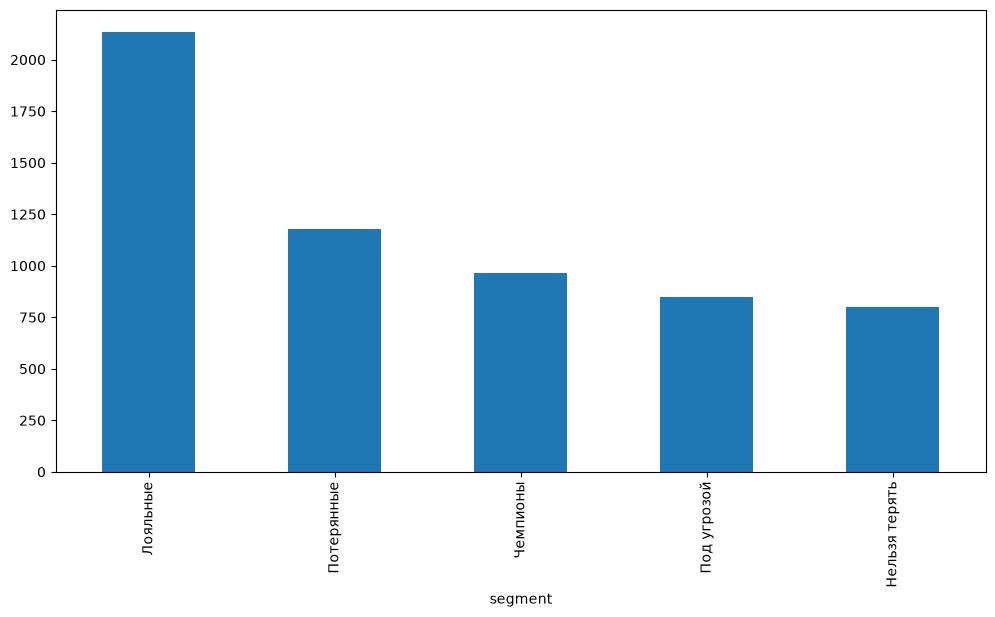

In [28]:
rfm.plot(
    kind='bar',
    x='segment',
    y='customers',
    legend=False
)

Наибольшую долю клиентской базы занимают лояльные клиенты > 2000, однако около трети клиентов находятся в зоне риска и требуют удерживающих мероприятий.

<Axes: xlabel='segment'>

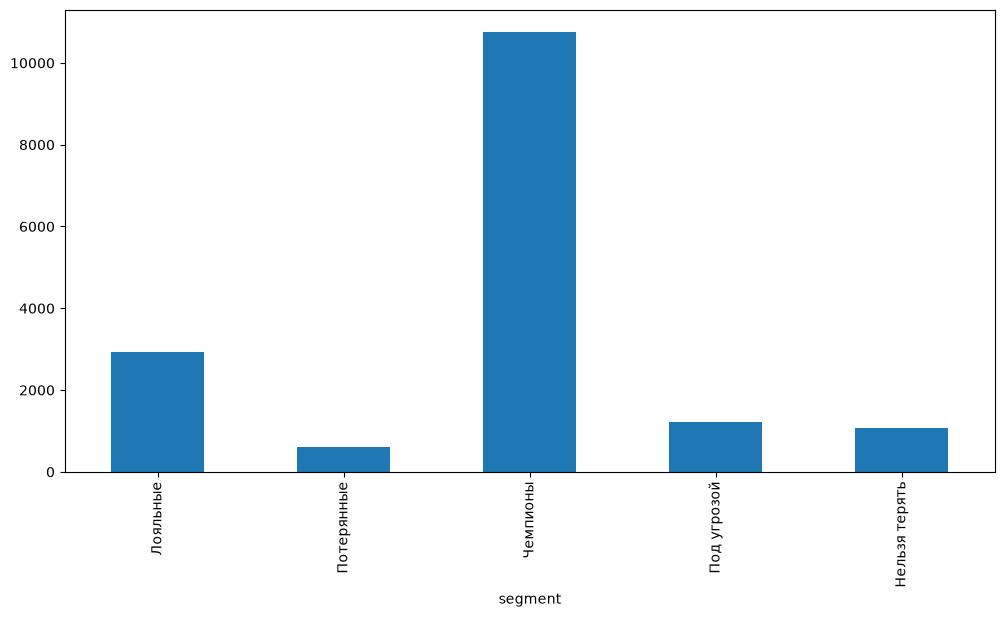

In [29]:
rfm.plot(
    kind='bar',
    x='segment',
    y='avg_revenue_per_customer',
    legend=False
)

Чемпионы формируют наибольшую ценность для бизнеса средняя выручка клиента почти в 4 раза выше, чем у лояльного сегмента

<Axes: xlabel='segment'>

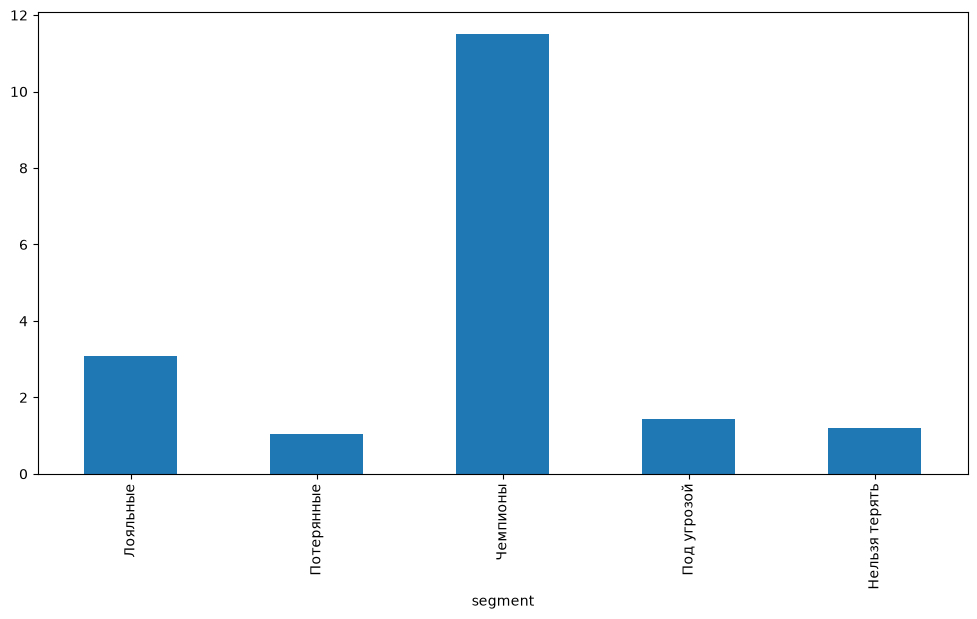

In [30]:
rfm.plot(
    kind='bar',
    x='segment',
    y='avg_purchases',
    legend=False
)

Так же чемпионы больше всех покупают, что подтверждает необходимость их удержания

<Axes: xlabel='segment'>

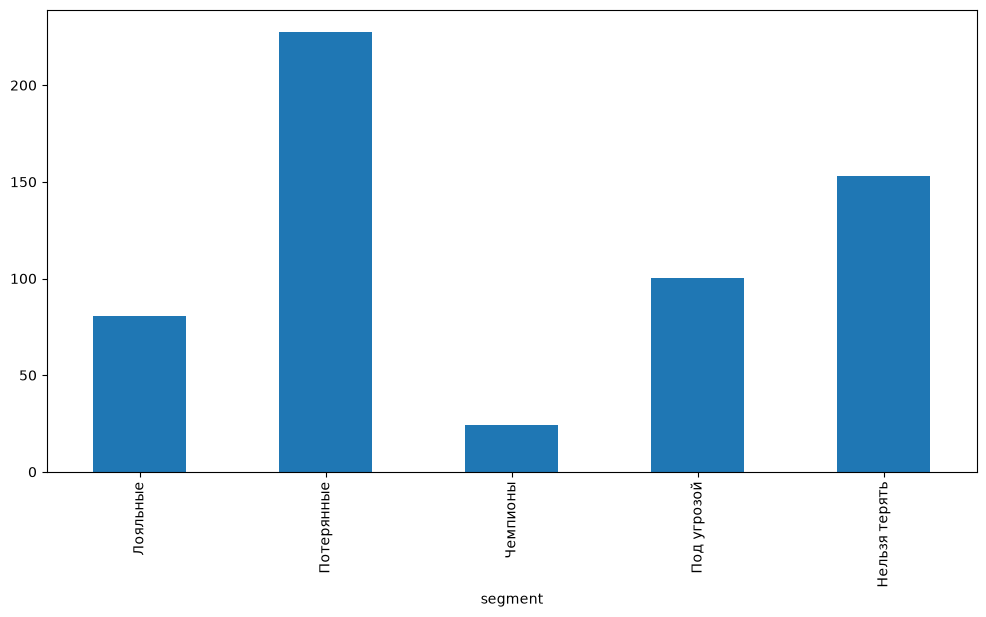

In [31]:
rfm.plot(
    kind='bar',
    x='segment',
    y='avg_days_since_purchase',
    legend=False
)

Потерянные клиенты в среднем не совершали покупку более 7 месяцев

<Axes: title={'center': 'Распределение клиентов по RFM-сегментам'}>

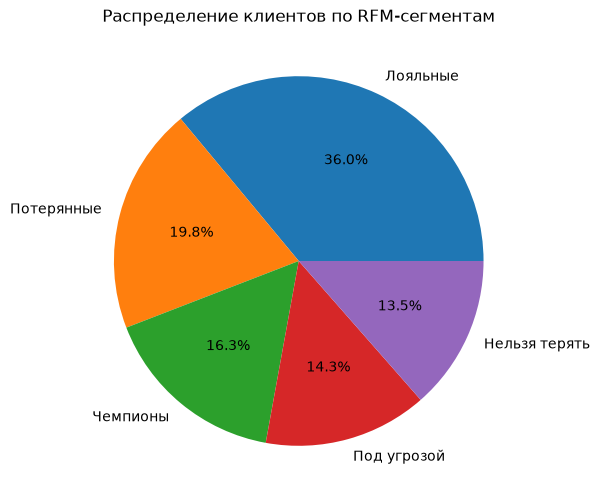

In [32]:
rfm.plot(
    kind='pie',
    y='customer_share_pct',
    labels=rfm['segment'],
    autopct='%1.1f%%',
    title='Распределение клиентов по RFM-сегментам',
    legend=False
)


### Выводы по результатам RFM-анализа

RFM-сегментация позволила выделить 5 групп клиентов с разным уровнем ценности и активности

Наибольшую долю клиентской базы составляют **лояльные клиенты (36%)** — это активная аудитория с потенциалом для удержания и увеличения среднего чека. Сегмент **"Чемпионы" (16%)** является наиболее ценным: клиенты совершают в среднем 11,5 покупок и формируют высокую выручку

При этом около **34% клиентов относятся к группам риска** ("Потерянные", "Под угрозой", "Нельзя терять"), что указывает на необходимость запуска кампаний удержания и возврата клиентов

### Бизнес-рекомендации по результатам RFM-анализа

| Сегмент           |               Стратегия на решение            |
|--------------|-----------------------------------------------|
|Чемпионы      | Программа лояльности с накопительными бонусами. Early access на новинки. Персональные подарки в день рождения.|
|Лояльные      | Программа «приведи друга» — Loyal обычно охотно рекомендуют. Кросс-селл в смежные категории.                        |
|Под угрозой   | Персональные предложения на основе истории покупок, напоминания о повторной покупке, бонус за возвращение  |
|Нельзя терять | Персональный win-back с агрессивной скидкой (20–30%).                  |
|Потерянные    |Удаление из CRM-кампаний (экономия на коммуникациях). Используем только для статистики и lookalike в платном трафике.                                               |

#### Основные точки роста:
- удержание и развитие сегментов "Чемпионы" и "Лояльные"
- реактивация клиентов "Под угрозой" и "Нельзя терять"
- оценка эффективности win-back кампаний для "Потерянных".